In [1]:
import pandas as pd
df = pd.read_csv("../data/Online_Retail_Cleaned.csv", sep=";")

In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Sales,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01.12.2010 08:26,"2,55","15,3",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01.12.2010 08:26,"3,39","20,34",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01.12.2010 08:26,"2,75",22,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01.12.2010 08:26,"3,39","20,34",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01.12.2010 08:26,"3,39","20,34",17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536641 entries, 0 to 536640
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  str    
 1   StockCode    536641 non-null  str    
 2   Description  535187 non-null  str    
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  str    
 5   UnitPrice    536641 non-null  str    
 6   Sales        536641 non-null  str    
 7   CustomerID   401604 non-null  float64
 8   Country      536641 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 36.8 MB


In [4]:
df.describe()

,Quantity,CustomerID
count,536641.000000,401604.000000
mean,9.620029,15281.160818
std,219.130156,1714.006089
min,-80995.000000,12346.000000
25%,1.000000,13939.000000
50%,3.000000,15145.000000
75%,10.000000,16784.000000
max,80995.000000,18287.000000


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
Sales               0
CustomerID     135037
Country             0
dtype: int64

In [6]:
df["Sales"].head()

0     15,3
1    20,34
2       22
3    20,34
4    20,34
Name: Sales, dtype: str

In [7]:
df["Sales"] = pd.to_numeric(df["Sales"].str.replace(",", "."), errors="coerce")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 536641 entries, 0 to 536640
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  str    
 1   StockCode    536641 non-null  str    
 2   Description  535187 non-null  str    
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  str    
 5   UnitPrice    536641 non-null  str    
 6   Sales        536641 non-null  float64
 7   CustomerID   401604 non-null  float64
 8   Country      536641 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 36.8 MB


In [9]:
df["Sales"].head()

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: Sales, dtype: float64

In [10]:
top_countries = (df.groupby("Description")["Sales"].sum().sort_values(ascending=False).head(10))
print(top_countries)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Sales, dtype: float64


In [11]:
top_products = (df.groupby("Description")["Sales"].sum().sort_values(ascending=False).head(10))
print(top_products)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164459.49
WHITE HANGING HEART T-LIGHT HOLDER     99612.42
PARTY BUNTING                          98243.88
JUMBO BAG RED RETROSPOT                92175.79
RABBIT NIGHT LIGHT                     66661.63
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63715.24
ASSORTED COLOUR BIRD ORNAMENT          58792.42
CHILLI LIGHTS                          53746.66
Name: Sales, dtype: float64


In [12]:
top_customers = (df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False).head(10))
print(top_customers)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Sales, dtype: float64


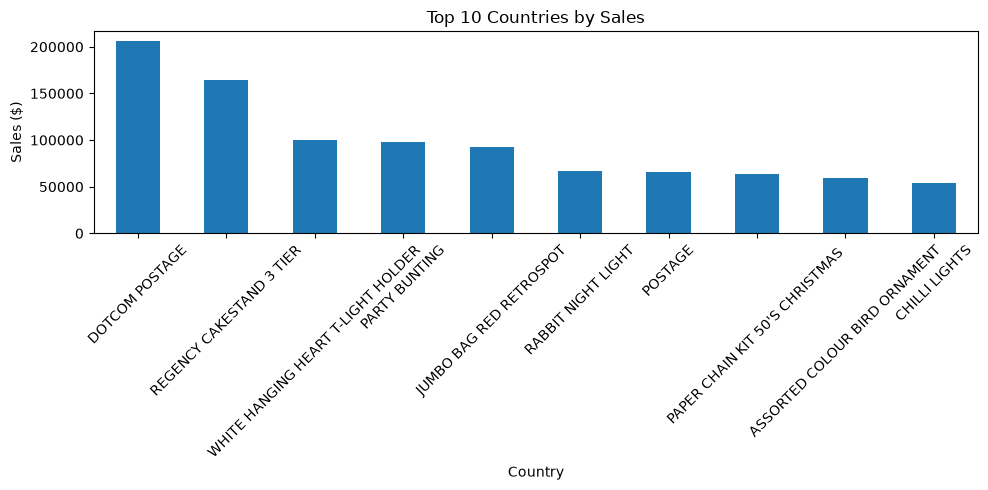

In [14]:
import matplotlib.pyplot as plt

top_countries.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/top_countries_python.png", dpi=300, bbox_inches="tight")

plt.show()

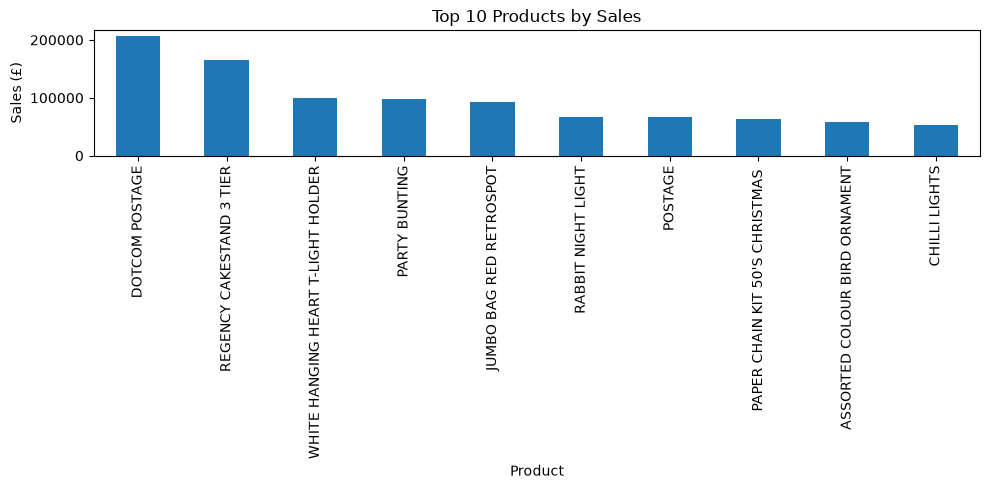

In [15]:
top_products = (
    df.groupby("Description")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales (£)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../images/top_products_python.png", dpi=300, bbox_inches="tight")

plt.show()

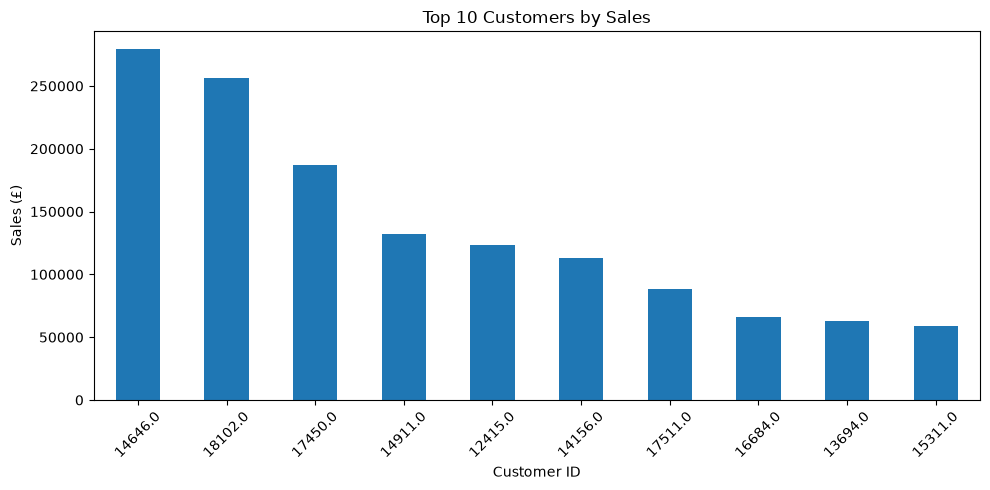

In [16]:
top_customers = (
    df.groupby("CustomerID")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Sales (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/top_customers_python.png", dpi=300, bbox_inches="tight")

plt.show()